## Analyse exploratoire de données (EDA)

In [1]:
# Importating necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
from scipy.stats import chi2_contingency
warnings.filterwarnings('ignore')

In [2]:
import os
os.listdir("../data/raw")

['smart_city_traffic_stress_dataset.csv']

In [3]:
# Loading dataset
data = pd.read_csv("../data/raw/smart_city_traffic_stress_dataset.csv")
data.head()

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
0,112,12.93,28.61,56.58,Foggy,7.31,Intermediate,68.37
1,61,7.43,54.22,35.64,Rainy,8.78,Beginner,47.14
2,102,11.07,41.42,54.61,Clear,8.34,Intermediate,55.02
3,24,1.54,69.86,16.09,Clear,6.29,Expert,22.71
4,116,11.60,33.01,62.51,Clear,8.19,Expert,49.91


In [4]:
# Checking the shape of the dataset
data.shape

(50000, 8)

In [5]:
# Statistical overview of the dataset
data.describe()

,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,road_quality_score,stress_index
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,64.42008,8.820749,54.256998,37.202482,6.940413,44.402318
std,31.72428,4.378499,13.647305,16.142846,1.885609,16.351604
min,10.00000,0.000000,13.860000,5.000000,1.000000,0.000000
25%,37.00000,5.540000,43.260000,23.360000,5.650000,31.620000
50%,64.00000,8.715000,54.250000,37.260000,7.000000,43.670000
75%,92.00000,11.910000,65.280000,50.880000,8.350000,56.270000
max,119.00000,24.860000,90.000000,74.500000,10.000000,100.000000


In [6]:
# General information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   traffic_density          50000 non-null  int64  
 1   horn_events_per_min      50000 non-null  float64
 2   avg_speed                50000 non-null  float64
 3   signal_wait_time         50000 non-null  float64
 4   weather_condition        50000 non-null  object 
 5   road_quality_score       50000 non-null  float64
 6   driver_experience_level  50000 non-null  object 
 7   stress_index             50000 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 3.1+ MB


In [7]:
# Checking for missing values
data.isnull().sum()

traffic_density            0
horn_events_per_min        0
avg_speed                  0
signal_wait_time           0
weather_condition          0
road_quality_score         0
driver_experience_level    0
stress_index               0
dtype: int64

In [8]:
# Checking for deuplicates in the dataset
data.duplicated().sum()

np.int64(0)

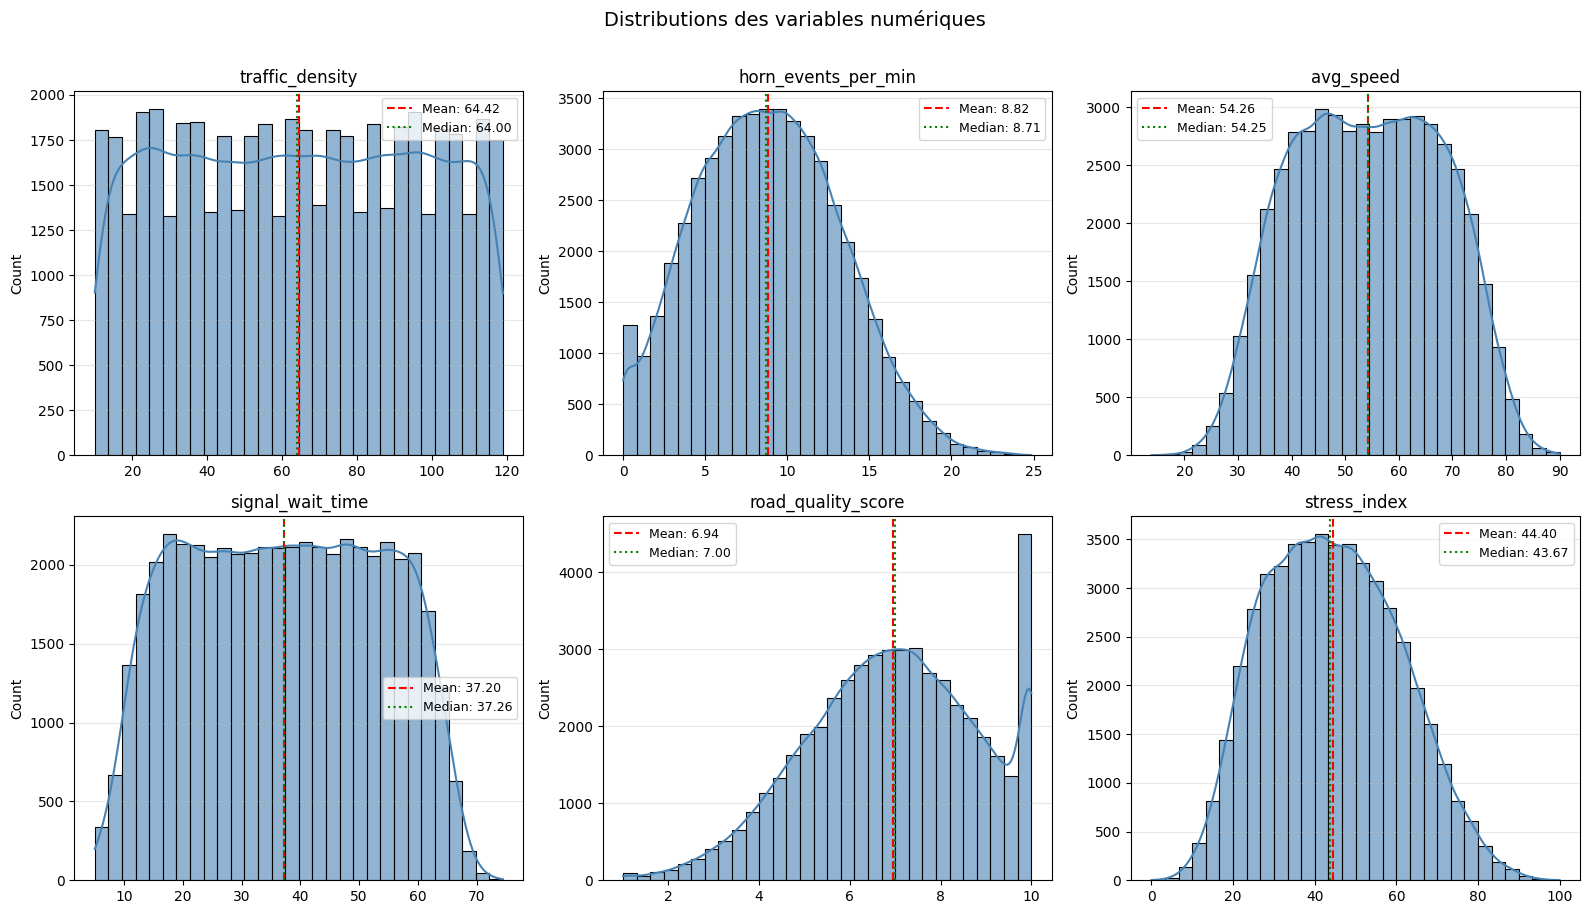

In [9]:
# Distribution of numerical variables
num_cols = ['traffic_density', 'horn_events_per_min', 'avg_speed', 'signal_wait_time', 'road_quality_score', 'stress_index']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(data=data, x=col, kde=True, ax=ax, color='steelblue', alpha=0.6, bins=30)
    mean_val = data[col].mean()
    median_val = data[col].median()
    ax.axvline(mean_val,   color='red',    linestyle='--', lw=1.5, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle=':',  lw=1.5, label=f'Median: {median_val:.2f}')
    
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distributions des variables numériques', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

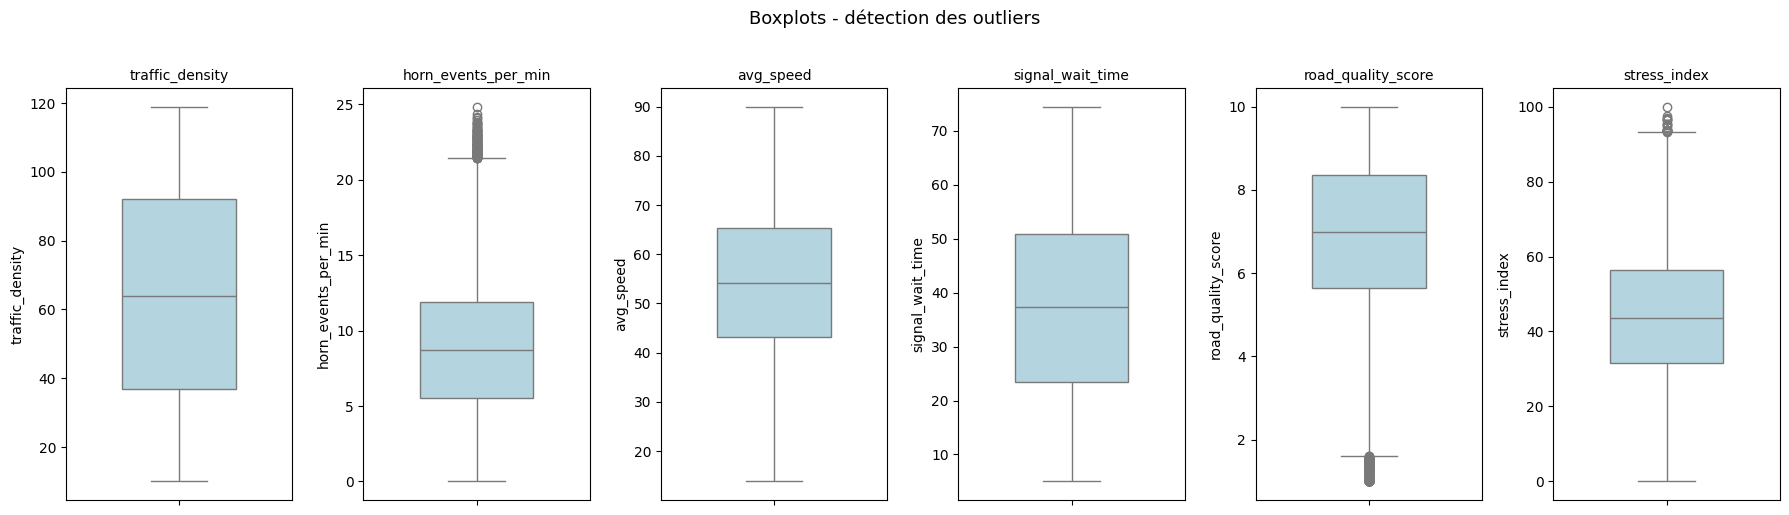

In [10]:
# Boxplots for outlier detection
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='lightblue', width=0.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots - détection des outliers', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

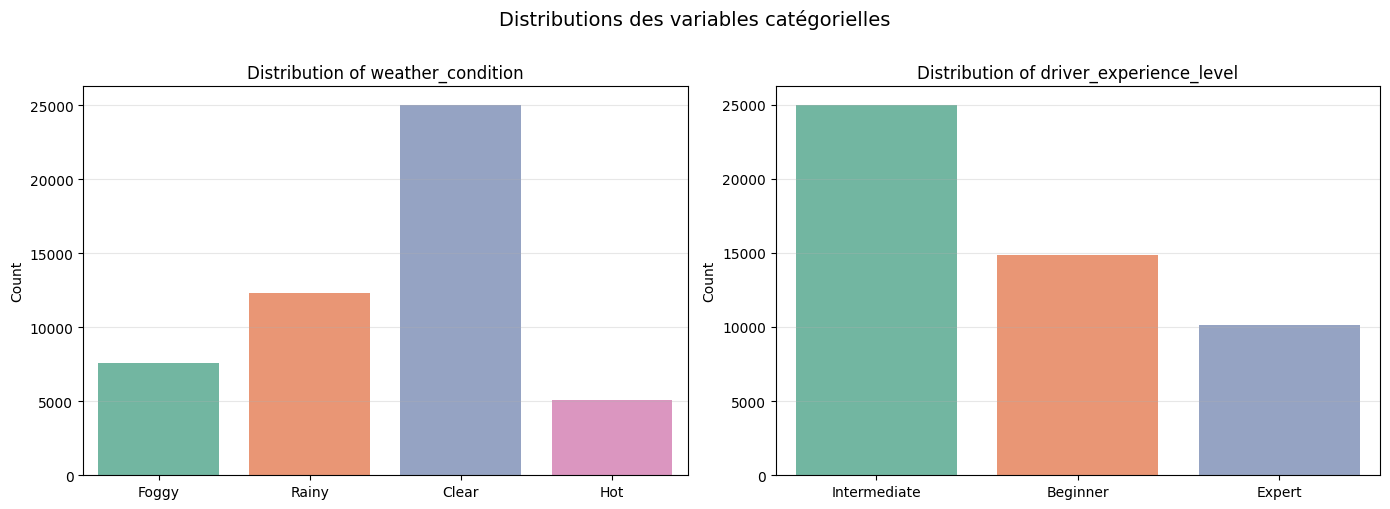

In [11]:
# Distribution of categorical variables with their counts
cat_cols = ['weather_condition', 'driver_experience_level']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(data=data, x=col, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Distributions des variables catégorielles', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Statistical test for categorical variables (Chi-squared test)
for col in cat_cols:
    counts = data[col].value_counts()
    pcts = counts / len(data) * 100
    max_gap = pcts.max() - pcts.min()
    print(f"{col} → écart max entre classes : {max_gap:.1f}% → {'à surveiller' if max_gap > 20 else 'acceptable'}")

weather_condition → écart max entre classes : 39.9% → à surveiller
driver_experience_level → écart max entre classes : 29.7% → à surveiller


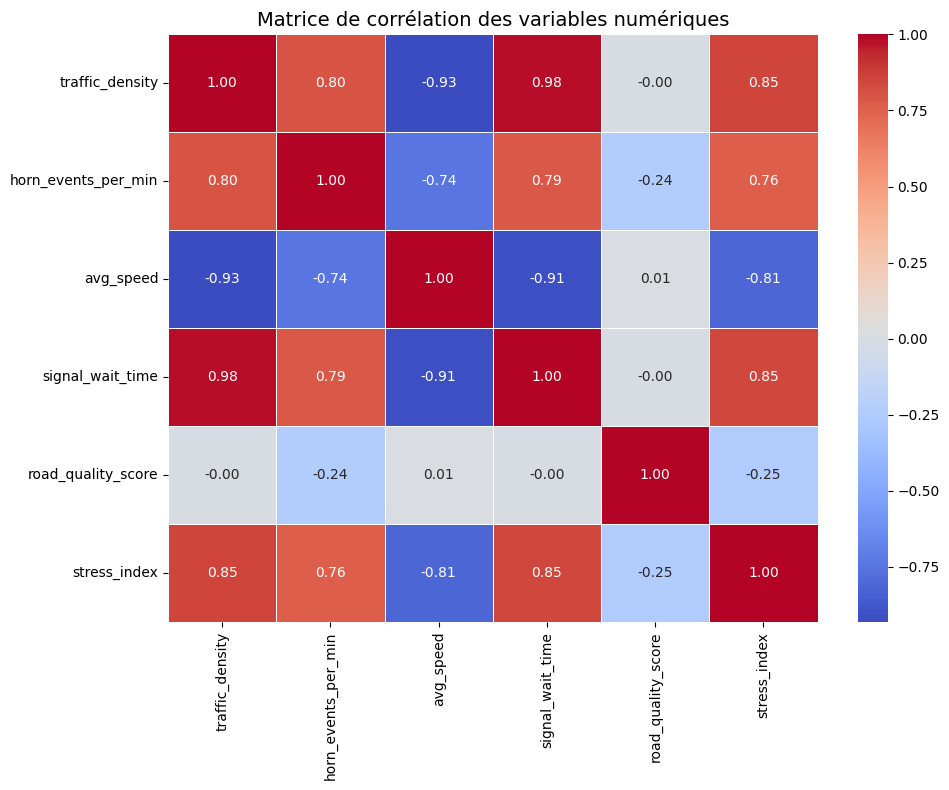

In [13]:
# Correlation matrix for numerical variables
plt.figure(figsize=(10, 8))
corr_matrix = data[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

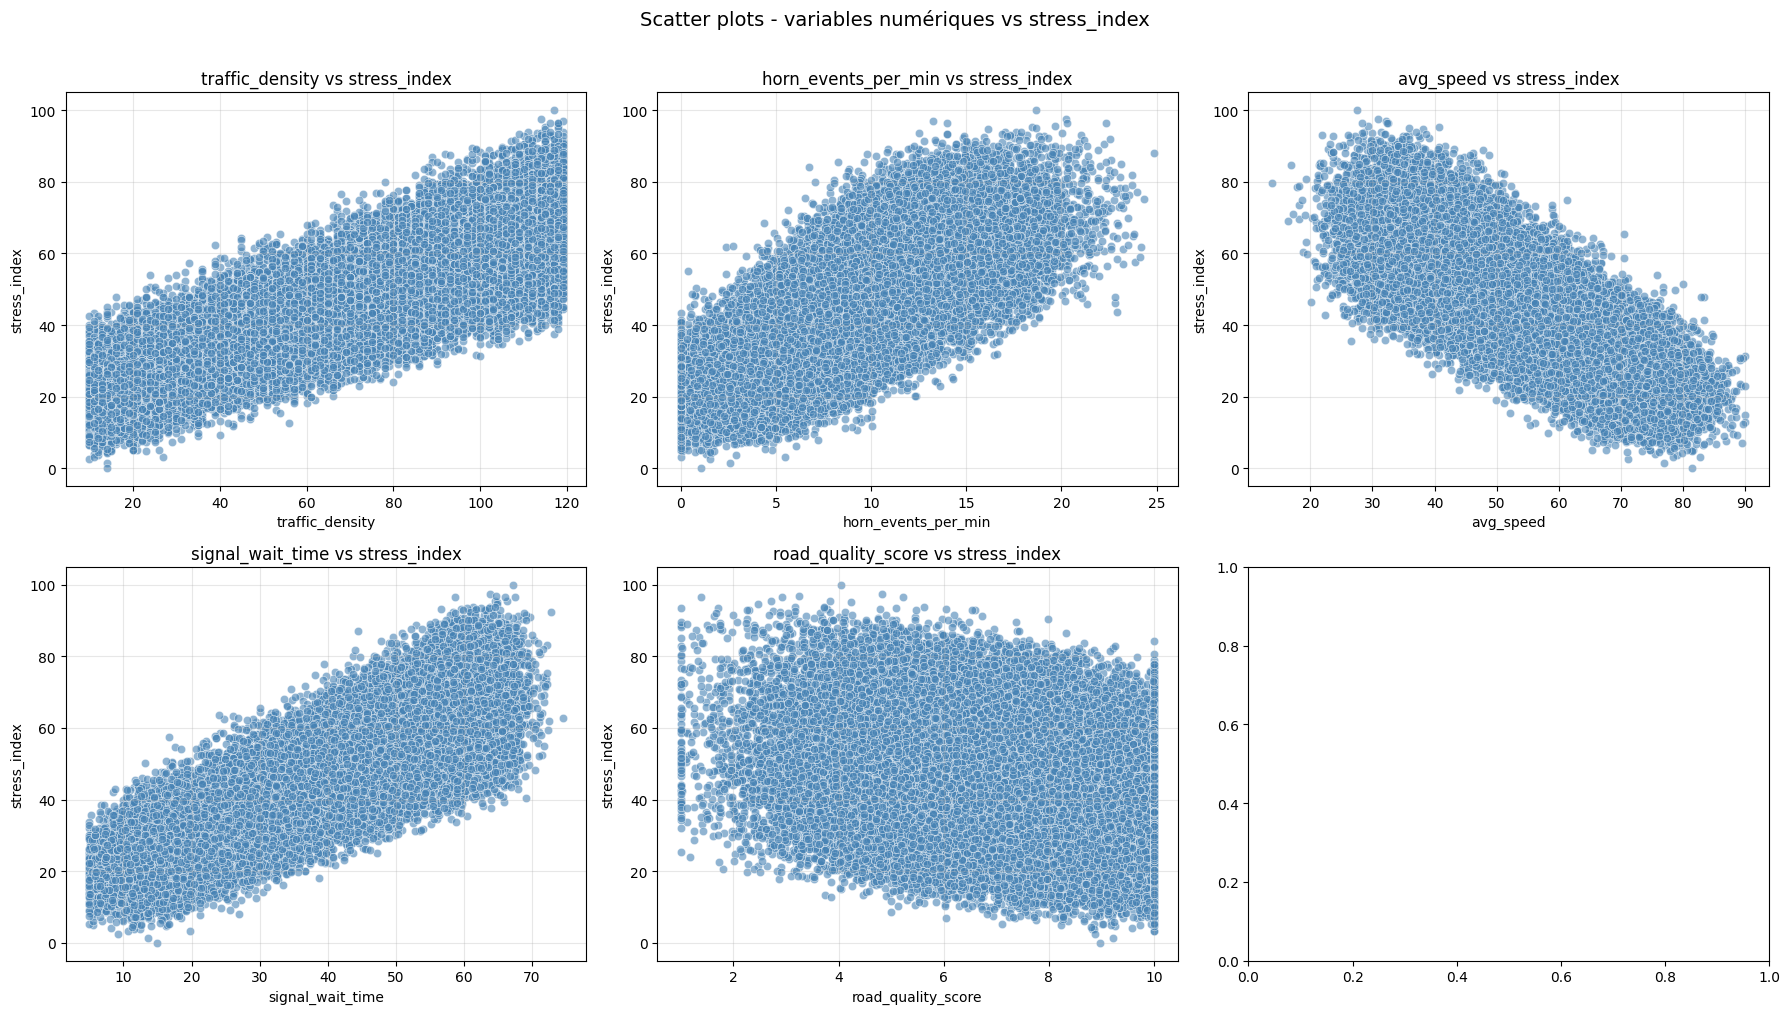

In [14]:
# Scatter plots for numerical variables vs target variable
target_col = 'stress_index'
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols[:-1]):
    ax = axes[i]
    sns.scatterplot(data=data, x=col, y=target_col, ax=ax, color='steelblue', alpha=0.6)
    ax.set_title(f'{col} vs {target_col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.grid(alpha=0.3)
plt.suptitle('Scatter plots - variables numériques vs stress_index', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()


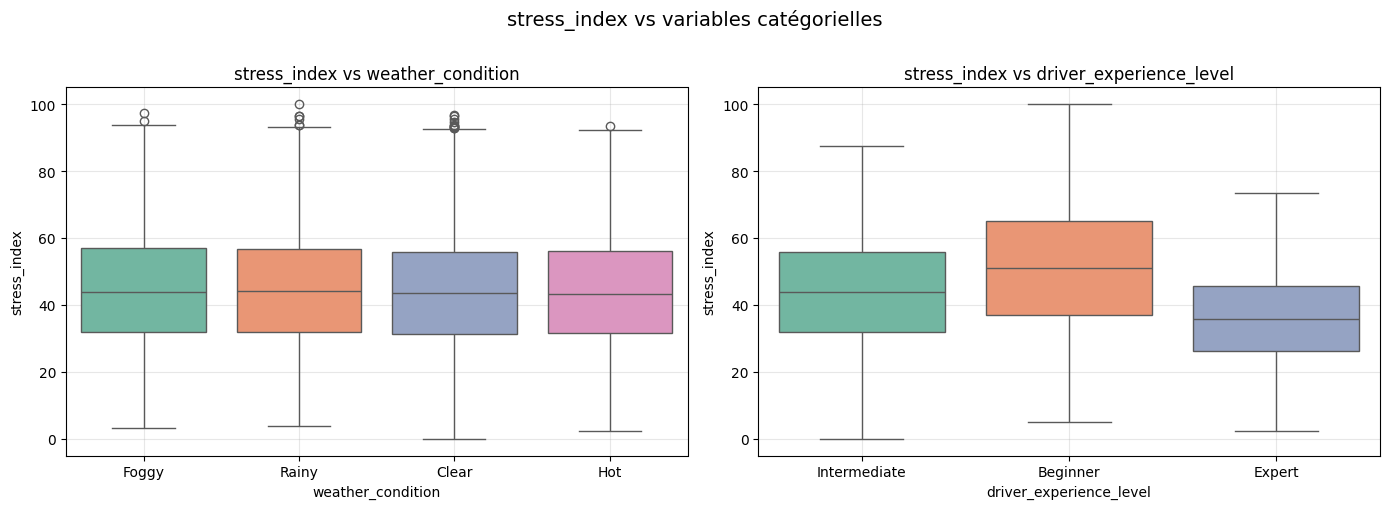

In [15]:
# Relationship between Stress index and categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.boxplot(data=data, x=col, y=target_col, ax=ax, palette='Set2')
    ax.set_title(f'{target_col} vs {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.grid(alpha=0.3)
plt.suptitle(f'{target_col} vs variables catégorielles', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/stress_vs_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


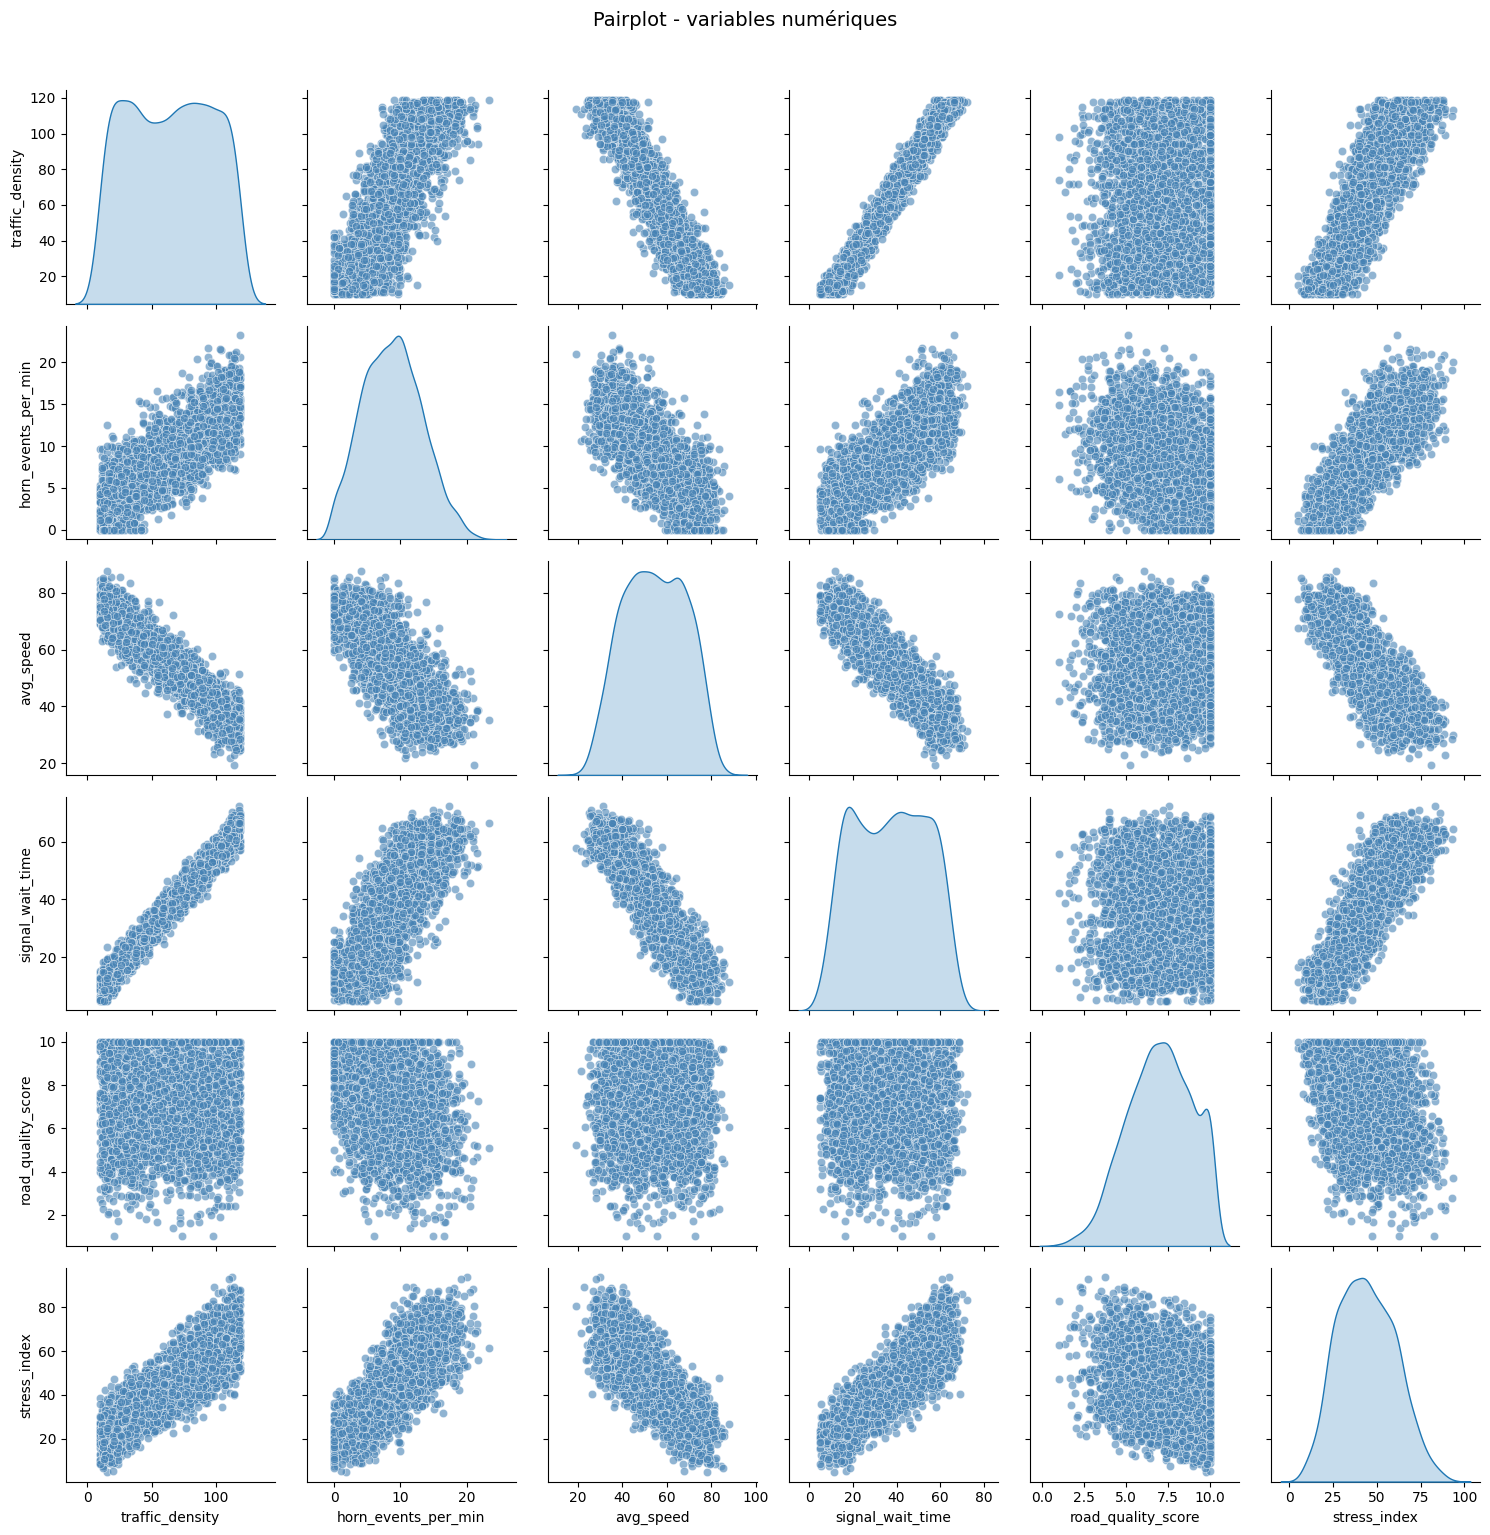

In [16]:
# Relationship between Stress index and numerical variables (pairplot)
sample = data[num_cols].sample(3000, random_state=42)
sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.6, 'color': 'steelblue'})
plt.suptitle('Pairplot - variables numériques', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Outlier detection using IQR method
outliers = {}
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
print("Outliers detected using IQR method:")
for col, out in outliers.items():
    print(f"{col}: {len(out)} outliers")

Outliers detected using IQR method:
traffic_density: 0 outliers
horn_events_per_min: 102 outliers
avg_speed: 0 outliers
signal_wait_time: 0 outliers
road_quality_score: 156 outliers
stress_index: 18 outliers


### **Conclusion**

 **QUALITÉ DES DONNÉES**   
  ✓  50 000 observations, 8 variables  
  ✓  0 valeur manquante - dataset propre  
  ✓  0 doublon

 **DISTRIBUTIONS**   
  ✓  avg_speed et stress_index : distributions quasi-normales  
  ✓  traffic_density et signal_wait_time : distributions quasi-uniformes  
  ~  road_quality_score : distribution légèrement asymétrique à gauche  
  ->  Aucune transformation (log, sqrt) nécessaire

 **OUTLIERS**   
  horn_events_per_min : 102 (0.20%) | road_quality_score : 156 (0.31%)  
  stress_index : 18 (0.04%)  
  ->  Volume négligeable - outliers conservés  

 **CORRÉLATIONS AVEC STRESS_INDEX**   
  (++) traffic_density     r=+0.85   (++) signal_wait_time  r=+0.85  
  (++) horn_events/min     r=+0.76   (--) avg_speed         r=-0.81  
  (~)  road_quality_score  r=-0.25  
  ->  3 features très corrélées entre elles -> multicolinéarité à traiter  

 **VARIABLES CATÉGORIELLES**   
  weather_condition       : 4 modalités, écart max 39.9% -> à surveiller  
  driver_experience_level : 3 modalités, écart max 29.7% -> à surveiller  
  ->  Encodage : Ordinal (experience) + One-Hot (weather)  

 **PROCHAINE ÉTAPE : PREPROCESSING**   
  Le notebook 02_processing.ipynb prendra en charge :  
  • L'encodage des variables catégorielles  
  • La création de features composites (feature engineering)  
  • La résolution de la multicolinéarité via VIF (Variance Inflation Factor ou encore Facteur d'Inflation de la Variance)  
  • La préparation de deux datasets adaptés aux modèles linéaires et aux modèles à base d'arbres  